In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../Smart_Farming_Crop_Yield_2024.csv")

df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 500
Number of columns: 22


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    str    
 1   region                500 non-null    str    
 2   crop_type             500 non-null    str    
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    str    
 10  fertilizer_type       500 non-null    str    
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    str    
 13  harvest_date          500 non-null    str    
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  500 non-null

In [6]:
df.columns.tolist()

['farm_id',
 'region',
 'crop_type',
 'soil_moisture_%',
 'soil_pH',
 'temperature_C',
 'rainfall_mm',
 'humidity_%',
 'sunlight_hours',
 'irrigation_type',
 'fertilizer_type',
 'pesticide_usage_ml',
 'sowing_date',
 'harvest_date',
 'total_days',
 'yield_kg_per_hectare',
 'sensor_id',
 'timestamp',
 'latitude',
 'longitude',
 'NDVI_index',
 'crop_disease_status']

In [7]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values("Missing_Percentage", ascending=False)

,Missing_Count,Missing_Percentage
irrigation_type,150,30.0
crop_disease_status,130,26.0
crop_type,0,0.0
soil_moisture_%,0,0.0
farm_id,0,0.0
region,0,0.0
temperature_C,0,0.0
soil_pH,0,0.0
humidity_%,0,0.0
rainfall_mm,0,0.0


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
df.describe()

,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,yield_kg_per_hectare,latitude,longitude,NDVI_index
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,26.750140,6.523980,24.675740,181.685740,65.194460,7.03014,26.586980,119.496000,4032.92694,22.442473,80.392248,0.602060
std,10.150053,0.585558,5.348899,72.293091,14.642849,1.69167,13.202429,16.798046,1174.43304,7.283492,5.910664,0.175402
min,10.160000,5.510000,15.000000,50.170000,40.230000,4.01000,5.050000,90.000000,2023.56000,10.004243,70.020021,0.300000
25%,17.890000,6.030000,20.295000,119.217500,51.865000,5.66750,14.945000,105.750000,2994.82000,16.263202,75.374713,0.447500
50%,25.855000,6.530000,24.655000,191.545000,65.685000,6.99500,25.980000,119.000000,4071.69000,21.981743,80.650284,0.610000
75%,36.022500,7.040000,29.090000,239.035000,77.995000,8.47000,38.005000,134.000000,5062.11000,28.528948,85.654629,0.750000
max,44.980000,7.500000,34.840000,298.960000,90.000000,10.00000,49.940000,150.000000,5998.29000,34.981531,89.991901,0.900000


In [10]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_report = missing_report[missing_report["Missing_Count"] > 0]

missing_report.sort_values(
    by="Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
irrigation_type,150,30.0
crop_disease_status,130,26.0


In [11]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [12]:
categorical_columns = df.select_dtypes(include=["object", "str"]).columns

for col in categorical_columns:
    print("\n" + "=" * 50)
    print(col)
    print("Unique values:", df[col].nunique(dropna=True))
    print(df[col].value_counts(dropna=False))


farm_id
Unique values: 500
farm_id
FARM0001    1
FARM0002    1
FARM0003    1
FARM0004    1
FARM0005    1
           ..
FARM0496    1
FARM0497    1
FARM0498    1
FARM0499    1
FARM0500    1
Name: count, Length: 500, dtype: int64

region
Unique values: 5
region
Central USA    109
East Africa    107
North India     99
South USA       94
South India     91
Name: count, dtype: int64

crop_type
Unique values: 5
crop_type
Maize      111
Soybean    108
Cotton     107
Wheat       92
Rice        82
Name: count, dtype: int64

irrigation_type
Unique values: 3
irrigation_type
NaN          150
Sprinkler    121
Manual       118
Drip         111
Name: count, dtype: int64

fertilizer_type
Unique values: 3
fertilizer_type
Inorganic    167
Mixed        167
Organic      166
Name: count, dtype: int64

sowing_date
Unique values: 84
sowing_date
2024-03-05    15
2024-03-07    11
2024-03-04     9
2024-02-02     9
2024-03-10     9
              ..
2024-03-13     3
2024-02-08     3
2024-01-15     2
2024-01-12  

In [13]:
print("Unique farm IDs:", df["farm_id"].nunique())
print("Unique sensor IDs:", df["sensor_id"].nunique())

Unique farm IDs: 500
Unique sensor IDs: 500


In [14]:
date_columns = [
    "sowing_date",
    "harvest_date",
    "timestamp"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

df[date_columns].dtypes

sowing_date     datetime64[us]
harvest_date    datetime64[us]
timestamp       datetime64[us]
dtype: object

In [15]:
for col in date_columns:
    print(
        col,
        "invalid/missing:",
        df[col].isna().sum()
    )

sowing_date invalid/missing: 0
harvest_date invalid/missing: 0
timestamp invalid/missing: 0


In [16]:
calculated_days = (
    df["harvest_date"] - df["sowing_date"]
).dt.days

date_difference = (
    calculated_days - df["total_days"]
).abs()

print("Maximum difference:", date_difference.max())
print("Rows with mismatch:", (date_difference > 0).sum())

Maximum difference: 0
Rows with mismatch: 0


In [17]:
print(df["yield_kg_per_hectare"].describe())

count     500.00000
mean     4032.92694
std      1174.43304
min      2023.56000
25%      2994.82000
50%      4071.69000
75%      5062.11000
max      5998.29000
Name: yield_kg_per_hectare, dtype: float64


In [18]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numerical_columns:
    print(
        f"{col}: "
        f"min={df[col].min()}, "
        f"max={df[col].max()}"
    )

soil_moisture_%: min=10.16, max=44.98
soil_pH: min=5.51, max=7.5
temperature_C: min=15.0, max=34.84
rainfall_mm: min=50.17, max=298.96
humidity_%: min=40.23, max=90.0
sunlight_hours: min=4.01, max=10.0
pesticide_usage_ml: min=5.05, max=49.94
total_days: min=90, max=150
yield_kg_per_hectare: min=2023.56, max=5998.29
latitude: min=10.004243, max=34.981531
longitude: min=70.020021, max=89.991901
NDVI_index: min=0.3, max=0.9


In [19]:
assert (df["yield_kg_per_hectare"] >= 0).all()
assert (df["soil_pH"] > 0).all()
assert (df["rainfall_mm"] >= 0).all()
assert (df["humidity_%"].between(0, 100)).all()
assert (df["soil_moisture_%"].between(0, 100)).all()
assert (df["NDVI_index"].between(-1, 1)).all()

print("Basic data-quality checks passed.")

Basic data-quality checks passed.


In [20]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working shape:", df_clean.shape)

Original shape: (500, 22)
Working shape: (500, 22)


In [21]:
categorical_missing_columns = [
    "irrigation_type",
    "crop_disease_status"
]

for col in categorical_missing_columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

print(df_clean[categorical_missing_columns].isnull().sum())

irrigation_type        0
crop_disease_status    0
dtype: int64


In [22]:
identifier_columns = [
    "farm_id",
    "sensor_id"
]

df_clean = df_clean.drop(
    columns=identifier_columns
)

print("Shape after removing identifiers:", df_clean.shape)

Shape after removing identifiers: (500, 20)


In [23]:
df_clean["sowing_month"] = df_clean["sowing_date"].dt.month
df_clean["sowing_day"] = df_clean["sowing_date"].dt.day

df_clean["harvest_month"] = df_clean["harvest_date"].dt.month
df_clean["harvest_day"] = df_clean["harvest_date"].dt.day

df_clean["observation_month"] = df_clean["timestamp"].dt.month
df_clean["observation_day"] = df_clean["timestamp"].dt.day

In [24]:
df_clean["days_since_sowing"] = (
    df_clean["timestamp"] - df_clean["sowing_date"]
).dt.days

df_clean["days_to_harvest"] = (
    df_clean["harvest_date"] - df_clean["timestamp"]
).dt.days

In [25]:
df_clean[
    [
        "sowing_date",
        "timestamp",
        "harvest_date",
        "days_since_sowing",
        "days_to_harvest"
    ]
].head(10)

,sowing_date,timestamp,harvest_date,days_since_sowing,days_to_harvest
0,2024-01-08,2024-03-19,2024-05-09,71,51
1,2024-02-04,2024-04-21,2024-05-26,77,35
2,2024-02-03,2024-02-28,2024-06-26,25,119
3,2024-02-21,2024-05-14,2024-07-04,83,51
4,2024-02-05,2024-04-13,2024-05-20,68,37
5,2024-01-13,2024-03-12,2024-05-06,59,55
6,2024-03-04,2024-07-11,2024-07-27,129,16
7,2024-01-24,2024-04-30,2024-05-24,97,24
8,2024-03-12,2024-05-08,2024-07-08,57,61
9,2024-01-18,2024-03-31,2024-04-25,73,25


In [26]:
invalid_timestamps = (
    (df_clean["timestamp"] < df_clean["sowing_date"]) |
    (df_clean["timestamp"] > df_clean["harvest_date"])
)

print("Observations outside crop cycle:", invalid_timestamps.sum())

Observations outside crop cycle: 0


In [27]:
df_clean["crop_cycle_progress"] = (
    df_clean["days_since_sowing"] /
    df_clean["total_days"]
)

df_clean["crop_cycle_progress"] = df_clean[
    "crop_cycle_progress"
].clip(0, 1)

In [28]:
df_clean["crop_cycle_progress"].describe()

count    500.000000
mean       0.498614
std        0.291976
min        0.000000
25%        0.232261
50%        0.500000
75%        0.759549
max        1.000000
Name: crop_cycle_progress, dtype: float64

In [29]:
raw_date_columns = [
    "sowing_date",
    "harvest_date",
    "timestamp"
]

df_clean = df_clean.drop(
    columns=raw_date_columns
)

print("Current shape:", df_clean.shape)

Current shape: (500, 26)


In [33]:
df_clean.head()

df_clean.info()

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   region                500 non-null    str    
 1   crop_type             500 non-null    str    
 2   soil_moisture_%       500 non-null    float64
 3   soil_pH               500 non-null    float64
 4   temperature_C         500 non-null    float64
 5   rainfall_mm           500 non-null    float64
 6   humidity_%            500 non-null    float64
 7   sunlight_hours        500 non-null    float64
 8   irrigation_type       500 non-null    str    
 9   fertilizer_type       500 non-null    str    
 10  pesticide_usage_ml    500 non-null    float64
 11  total_days            500 non-null    int64  
 12  yield_kg_per_hectare  500 non-null    float64
 13  latitude              500 non-null    float64
 14  longitude             500 non-null    float64
 15  NDVI_index            500 non-null

In [34]:
remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

print(remaining_missing)

Series([], dtype: int64)


In [35]:
target = "yield_kg_per_hectare"

print("Target:", target)
print("Target missing:", df_clean[target].isnull().sum())
print("Target dtype:", df_clean[target].dtype)

Target: yield_kg_per_hectare
Target missing: 0
Target dtype: float64


In [36]:
X = df_clean.drop(columns=[target])
y = df_clean[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (500, 25)
Target shape: (500,)


In [37]:
potential_leakage = [
    "yield_kg_per_hectare",
    "harvest_month",
    "harvest_day",
    "days_to_harvest"
]

df_clean[potential_leakage].head()

,yield_kg_per_hectare,harvest_month,harvest_day,days_to_harvest
0,4408.07,5,9,51
1,5389.98,5,26,35
2,2931.16,6,26,119
3,4227.80,7,4,51
4,4979.96,5,20,37


In [38]:
features = [
    "region",
    "crop_type",
    "soil_moisture_%",
    "soil_pH",
    "temperature_C",
    "rainfall_mm",
    "humidity_%",
    "sunlight_hours",
    "irrigation_type",
    "fertilizer_type",
    "pesticide_usage_ml",
    "total_days",
    "latitude",
    "longitude",
    "NDVI_index",
    "crop_disease_status",
    "sowing_month",
    "sowing_day",
    "observation_month",
    "observation_day",
    "days_since_sowing",
    "crop_cycle_progress"
]

target = "yield_kg_per_hectare"

X = df_clean[features].copy()
y = df_clean[target].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (500, 22)
Target: (500,)


In [39]:
categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int32", "int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['region', 'crop_type', 'irrigation_type', 'fertilizer_type', 'crop_disease_status']

Numerical features:
['soil_moisture_%', 'soil_pH', 'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours', 'pesticide_usage_ml', 'total_days', 'latitude', 'longitude', 'NDVI_index', 'sowing_month', 'sowing_day', 'observation_month', 'observation_day', 'days_since_sowing', 'crop_cycle_progress']


In [40]:
correlation = df_clean[
    numerical_features + [target]
].corr()

correlation[target].sort_values(
    ascending=False
)

yield_kg_per_hectare    1.000000
pesticide_usage_ml      0.041290
humidity_%              0.039021
NDVI_index              0.038099
temperature_C           0.027875
soil_pH                 0.024274
longitude               0.022359
sunlight_hours          0.020284
crop_cycle_progress     0.008719
observation_month       0.005527
sowing_day              0.001849
days_since_sowing       0.000041
total_days             -0.007570
sowing_month           -0.016000
latitude               -0.038127
soil_moisture_%        -0.063038
observation_day        -0.071119
rainfall_mm            -0.076802
Name: yield_kg_per_hectare, dtype: float64

In [42]:
import seaborn as sns

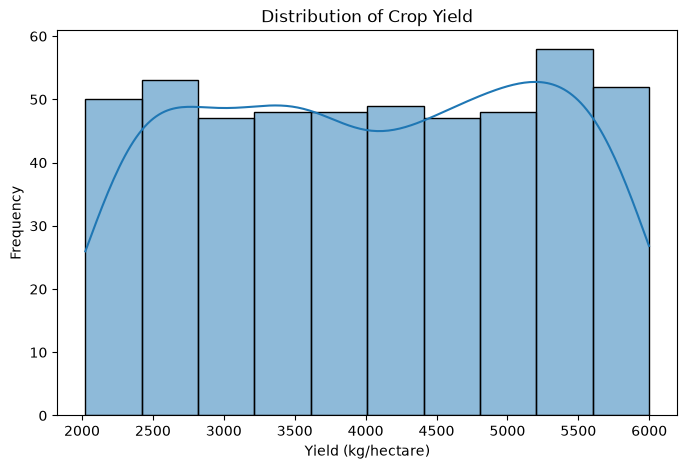

In [43]:
plt.figure(figsize=(8, 5))

sns.histplot(
    y,
    kde=True
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg/hectare)")
plt.ylabel("Frequency")

plt.show()

In [44]:
print("Mean yield:", y.mean())
print("Median yield:", y.median())
print("Minimum yield:", y.min())
print("Maximum yield:", y.max())
print("Standard deviation:", y.std())

Mean yield: 4032.92694
Median yield: 4071.6899999999996
Minimum yield: 2023.56
Maximum yield: 5998.29
Standard deviation: 1174.4330399391179


In [45]:
Q1 = X[numerical_features].quantile(0.25)
Q3 = X[numerical_features].quantile(0.75)

IQR = Q3 - Q1

outlier_mask = (
    (X[numerical_features] < (Q1 - 1.5 * IQR)) |
    (X[numerical_features] > (Q3 + 1.5 * IQR))
)

outlier_counts = outlier_mask.sum().sort_values(
    ascending=False
)

outlier_counts[outlier_counts > 0]

Series([], dtype: int64)

In [46]:
model_df = X.copy()

model_df[target] = y

print(model_df.shape)
model_df.head()

(500, 23)


,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,fertilizer_type,...,longitude,NDVI_index,crop_disease_status,sowing_month,sowing_day,observation_month,observation_day,days_since_sowing,crop_cycle_progress,yield_kg_per_hectare
0,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,Unknown,Organic,...,82.997689,0.63,Mild,1,8,3,19,71,0.581967,4408.07
1,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,Inorganic,...,70.869009,0.58,Unknown,2,4,4,21,77,0.687500,5389.98
2,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,Mixed,...,79.068206,0.80,Mild,2,3,2,28,25,0.173611,2931.16
3,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,Organic,...,85.519998,0.44,Unknown,2,21,5,14,83,0.619403,4227.80
4,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,Unknown,Mixed,...,81.691720,0.84,Severe,2,5,4,13,68,0.647619,4979.96


In [47]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=[target])
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (400, 22)
Testing features: (100, 22)
Training target: (400,)
Testing target: (100,)


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [53]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [55]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (400, 38)
Processed testing shape: (100, 38)


In [56]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

for i, feature in enumerate(feature_names, start=1):
    print(i, feature)

Number of processed features: 38
1 num__soil_moisture_%
2 num__soil_pH
3 num__temperature_C
4 num__rainfall_mm
5 num__humidity_%
6 num__sunlight_hours
7 num__pesticide_usage_ml
8 num__total_days
9 num__latitude
10 num__longitude
11 num__NDVI_index
12 num__sowing_month
13 num__sowing_day
14 num__observation_month
15 num__observation_day
16 num__days_since_sowing
17 num__crop_cycle_progress
18 cat__region_Central USA
19 cat__region_East Africa
20 cat__region_North India
21 cat__region_South India
22 cat__region_South USA
23 cat__crop_type_Cotton
24 cat__crop_type_Maize
25 cat__crop_type_Rice
26 cat__crop_type_Soybean
27 cat__crop_type_Wheat
28 cat__irrigation_type_Drip
29 cat__irrigation_type_Manual
30 cat__irrigation_type_Sprinkler
31 cat__irrigation_type_Unknown
32 cat__fertilizer_type_Inorganic
33 cat__fertilizer_type_Mixed
34 cat__fertilizer_type_Organic
35 cat__crop_disease_status_Mild
36 cat__crop_disease_status_Moderate
37 cat__crop_disease_status_Severe
38 cat__crop_disease_statu

In [57]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Training dataframe:", X_train_processed_df.shape)
print("Testing dataframe:", X_test_processed_df.shape)

Training dataframe: (400, 38)
Testing dataframe: (100, 38)


In [58]:
print(
    "Training missing values:",
    X_train_processed_df.isnull().sum().sum()
)

print(
    "Testing missing values:",
    X_test_processed_df.isnull().sum().sum()
)

Training missing values: 0
Testing missing values: 0


In [65]:
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTarget variable:")
print(target)

print("\nTraining target statistics:")
print(y_train.describe())

Training target: (400,)
Testing target: (100,)

Target variable:
yield_kg_per_hectare

Training target statistics:
count     400.000000
mean     4037.775650
std      1174.194159
min      2023.560000
25%      3020.495000
50%      4071.690000
75%      5076.812500
max      5998.290000
Name: yield_kg_per_hectare, dtype: float64


In [66]:
preprocessing_summary = {
    "Original rows": len(df),
    "Original columns": len(df.columns),
    "Duplicates removed": df.duplicated().sum(),
    "Final training samples": len(X_train),
    "Final testing samples": len(X_test),
    "Original candidate features": len(features),
    "Processed features": X_train_processed.shape[1],
    "Target": target
}

for key, value in preprocessing_summary.items():
    print(f"{key}: {value}")

Original rows: 500
Original columns: 22
Duplicates removed: 0
Final training samples: 400
Final testing samples: 100
Original candidate features: 22
Processed features: 38
Target: yield_kg_per_hectare


In [67]:
train_processed = X_train_processed_df.copy()
train_processed[target] = y_train

test_processed = X_test_processed_df.copy()
test_processed[target] = y_test

In [71]:
train_processed.to_csv(
    "../data/processed/train_processed.csv",
    index=False
)

test_processed.to_csv(
    "../data/processed/test_processed.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [72]:
import os

print(os.path.exists("../data/processed/train_processed.csv"))
print(os.path.exists("../data/processed/test_processed.csv"))

True
True
